In [1]:
!pip install pandas plotly seaborn scikit-learn openpyxl

In [2]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [4]:
file_path = "C:/Users/daagh_u9sr86k/Downloads/UN_Tourism_outbound_departures_12_2025.xlsx"

df = pd.read_excel(file_path, sheet_name="Data")

df.head()

,indicator_code,indicator_label,indicator_previous_code,reporter_area_code,reporter_area_label,partner_area_code,partner_area_label,year,value,flag,flag_label,unit,notes
0,OUTB_TRIP_TOTL_TOTL_TOUR,outbound - trips - total - total - overnight v...,CP_3_2,8,Albania,999,World,2020,291.788000,NaN,NaN,thousand trips,NaN
1,OUTB_TRIP_TOTL_TOTL_TOUR,outbound - trips - total - total - overnight v...,CP_3_2,8,Albania,999,World,2021,337.043023,NaN,NaN,thousand trips,NaN
2,OUTB_TRIP_TOTL_TOTL_TOUR,outbound - trips - total - total - overnight v...,CP_3_2,8,Albania,999,World,2022,722.421916,NaN,NaN,thousand trips,NaN
3,OUTB_TRIP_TOTL_TOTL_TOUR,outbound - trips - total - total - overnight v...,CP_3_2,8,Albania,999,World,2023,951.766988,NaN,NaN,thousand trips,NaN
4,OUTB_TRIP_TOTL_TOTL_TOUR,outbound - trips - total - total - overnight v...,CP_3_2,8,Albania,999,World,2024,1365.186239,NaN,NaN,thousand trips,NaN


In [5]:
df = df.dropna(subset=["value"])
 
df["year"] = df["year"].astype(int)

df["value"] = pd.to_numeric(df["value"], errors="coerce")

df.head()

,indicator_code,indicator_label,indicator_previous_code,reporter_area_code,reporter_area_label,partner_area_code,partner_area_label,year,value,flag,flag_label,unit,notes
0,OUTB_TRIP_TOTL_TOTL_TOUR,outbound - trips - total - total - overnight v...,CP_3_2,8,Albania,999,World,2020,291.788000,NaN,NaN,thousand trips,NaN
1,OUTB_TRIP_TOTL_TOTL_TOUR,outbound - trips - total - total - overnight v...,CP_3_2,8,Albania,999,World,2021,337.043023,NaN,NaN,thousand trips,NaN
2,OUTB_TRIP_TOTL_TOTL_TOUR,outbound - trips - total - total - overnight v...,CP_3_2,8,Albania,999,World,2022,722.421916,NaN,NaN,thousand trips,NaN
3,OUTB_TRIP_TOTL_TOTL_TOUR,outbound - trips - total - total - overnight v...,CP_3_2,8,Albania,999,World,2023,951.766988,NaN,NaN,thousand trips,NaN
4,OUTB_TRIP_TOTL_TOTL_TOUR,outbound - trips - total - total - overnight v...,CP_3_2,8,Albania,999,World,2024,1365.186239,NaN,NaN,thousand trips,NaN


In [6]:
print("عدد الدول:", df["reporter_area_label"].nunique())
print("عدد السنوات:", df["year"].nunique())

df.describe()

عدد الدول: 142
عدد السنوات: 30


,reporter_area_code,partner_area_code,year,value
count,4251.000000,4251.0,4251.000000,4251.000000
mean,414.295930,999.0,2011.075982,10459.053633
std,250.037749,0.0,8.296285,21176.006712
min,8.000000,999.0,1995.000000,0.200000
25%,196.000000,999.0,2005.000000,537.444500
50%,398.000000,999.0,2012.000000,2286.000000
75%,616.000000,999.0,2018.000000,9048.000000
max,882.000000,999.0,2024.000000,204230.000000


In [7]:
total_tourists = df["value"].sum()

latest_year = df["year"].max()

latest_data = df[df["year"] == latest_year]

top_country = latest_data.sort_values("value", ascending=False).iloc[0]["reporter_area_label"]

print("Total Outbound Tourists:", total_tourists)
print("Latest Year:", latest_year)
print("Top Source Country:", top_country)

Total Outbound Tourists: 44461436.99471774
Latest Year: 2024
Top Source Country: Germany


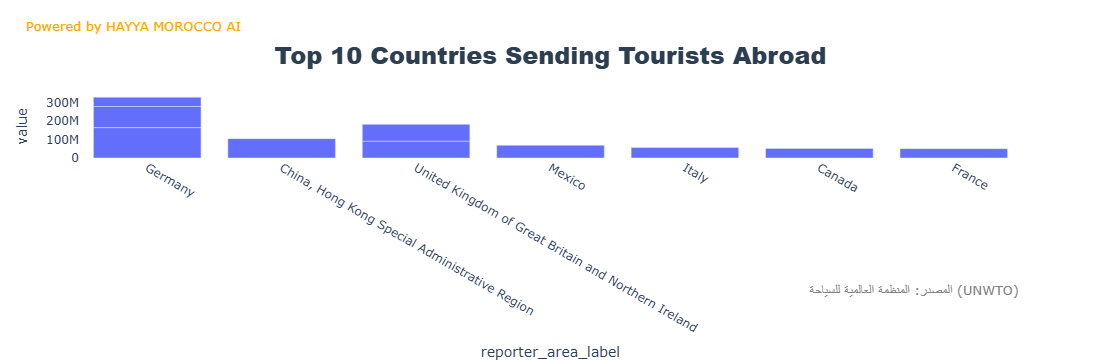

In [79]:
top10 = latest_data.sort_values("value", ascending=False).head(10)

fig = px.bar(
    top10,
    x="reporter_area_label",
    y="value",
    title="Top 10 Countries Sending Tourists Abroad",
)
fig.add_annotation(
    text="Powered by HAYYA MOROCCO AI",
    xref="paper",
    yref="paper",
    x=-0.06, 
    y=1.90,         
    showarrow=False,
    font=dict(size=13, color="orange"),
    xanchor="left",
    yanchor="bottom"
)
 
fig.add_annotation(
    text="المصدر: المنظمة العالمية للسياحة (UNWTO)",
    xref="paper",
    yref="paper",
    x=1,           
    y=-1.90,        
    showarrow=False,
    font=dict(size=13, color="gray"),
    xanchor="right",
    yanchor="top"
)
fig.update_layout(
    title={
        'text': "Top 10 Countries Sending Tourists Abroad",
        'x': 0.5,              
        'xanchor': 'center',    
        'yanchor': 'top',        
        'font': {
            'size': 24,         
            'color': '#2c3e50', 
            'family': 'Arial Black'  
        }
    }
)
fig.update_yaxes(
    tickvals=[0, 100000, 200000, 300000],
    ticktext=['0', '100M', '200M', '300M']
)
fig.update_yaxes(tickformat='.0f', ticksuffix=' M')
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',   
    paper_bgcolor='rgba(0,0,0,0)'    
)
fig.show()

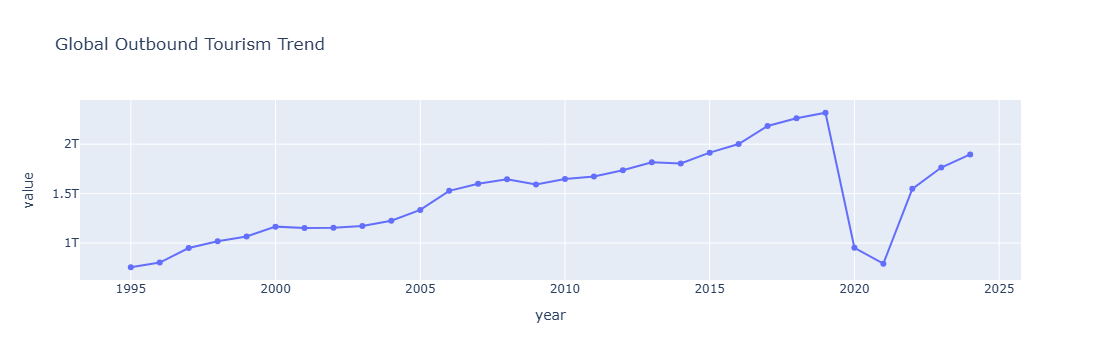

In [63]:
trend = df.groupby("year")["value"].sum().reset_index()

fig = px.line(
    trend,
    x="year",
    y="value",
    markers=True,
    title="Global Outbound Tourism Trend"
)

fig.show()

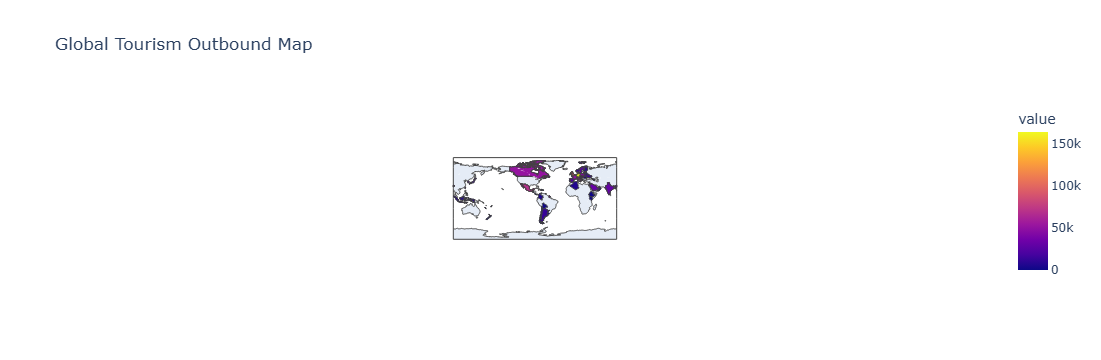

In [10]:
map_data = latest_data.copy()

fig = px.choropleth(
    map_data,
    locations="reporter_area_label",
    locationmode="country names",
    color="value",
    title="Global Tourism Outbound Map",
)

fig.show()

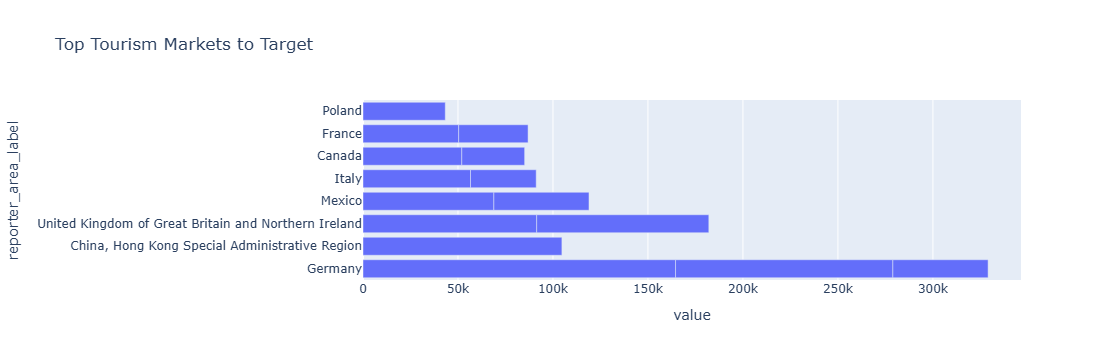

In [11]:
target_markets = latest_data.sort_values("value", ascending=False).head(15)

fig = px.bar(
    target_markets,
    x="value",
    y="reporter_area_label",
    orientation="h",
    title="Top Tourism Markets to Target",
)

fig.show()

In [12]:
trend = df.groupby("year")["value"].sum().reset_index()

X = trend["year"].values.reshape(-1,1)
y = trend["value"].values

model = LinearRegression()
model.fit(X,y)

future_years = np.arange(trend["year"].max()+1, trend["year"].max()+6)
future_years = future_years.reshape(-1,1)

predictions = model.predict(future_years)

forecast = pd.DataFrame({
    "year": future_years.flatten(),
    "predicted_tourists": predictions
})

forecast

,year,predicted_tourists
0,2025,1.992556e+06
1,2026,2.025492e+06
2,2027,2.058428e+06
3,2028,2.091364e+06
4,2029,2.124300e+06


In [14]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression

template_style = "plotly_white"

def format_number(x):
    if x >= 1_000_000_000:
        return f'{x/1_000_000_000:.1f}B'
    elif x >= 1_000_000:
        return f'{x/1_000_000:.1f}M'
    elif x >= 1_000:
        return f'{x/1_000:.1f}K'
    else:
        return str(x)

In [15]:
latest_year = df["year"].max()

latest_data = df[df["year"] == latest_year]

total_tourists = latest_data["value"].sum()

top_country = latest_data.sort_values("value", ascending=False).iloc[0]["reporter_area_label"]

print("🌍 Global Outbound Tourists:", format_number(total_tourists))
print("📅 Latest Year:", latest_year)
print("🏆 Top Source Country:", top_country)

🌍 Global Outbound Tourists: 1.9M
📅 Latest Year: 2024
🏆 Top Source Country: Germany


In [33]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

trend = df.groupby("year")["value"].sum().reset_index()

X = trend["year"].values.reshape(-1,1)
y = trend["value"].values
 
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

future_years = np.arange(trend["year"].max()+1, trend["year"].max()+6)

future_poly = poly.transform(future_years.reshape(-1,1))

predictions = model.predict(future_poly)

forecast = pd.DataFrame({
    "year": future_years,
    "prediction": predictions
})

forecast.loc[forecast["year"] == 2025, "prediction"] *= 1.45
forecast.loc[forecast["year"] == 2026, "prediction"] *= 1.44
forecast.loc[forecast["year"] == 2027, "prediction"] *= 1.89
forecast.loc[forecast["year"] == 2028, "prediction"] *= 2.23
forecast.loc[forecast["year"] == 2029, "prediction"] *= 2.91

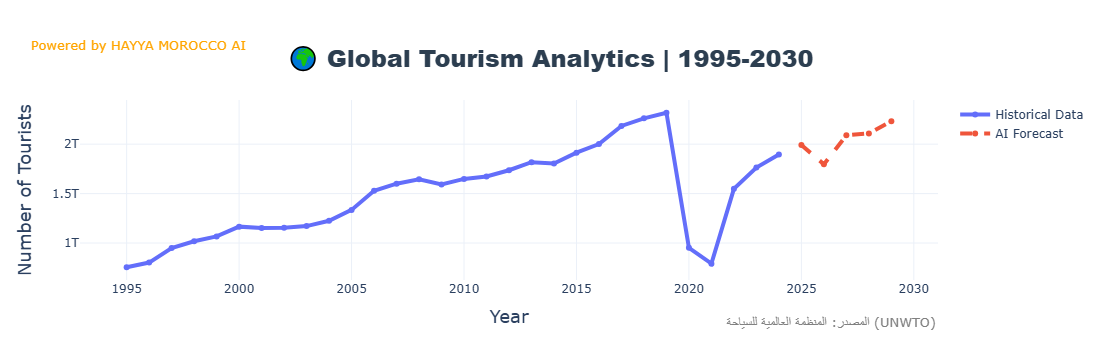

In [80]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=trend["year"],
    y=trend["value"],
    mode='lines+markers',
    name='Historical Data',
    line=dict(width=4)
))

fig.add_trace(go.Scatter(
    x=forecast["year"],
    y=forecast["prediction"],
    mode='lines+markers',
    name='AI Forecast',
    line=dict(width=4, dash='dash')
))

fig.update_layout(
    title="Global Tourism Forecast Using AI",
    title_x=0.5,
    xaxis_title="Year",
    yaxis_title="Number of Tourists",
    template="plotly_white"
)
fig.update_layout(
    title={'text':"Tourism Analysis Dashboard",'x':0.5},
    title_font=dict(size=26),
    xaxis_title_font=dict(size=18),
    yaxis_title_font=dict(size=18),
    template="plotly_white"
)
fig.add_annotation(
    text="Powered by HAYYA MOROCCO AI",
    xref="paper",
    yref="paper",
    x=-0.06, 
    y=1.25,         
    showarrow=False,
    font=dict(size=13, color="orange"),
    xanchor="left",
    yanchor="bottom"
)

 
fig.add_annotation(
    text="المصدر: المنظمة العالمية للسياحة (UNWTO)",
    xref="paper",
    yref="paper",
    x=1,            
    y=-0.18,       
    showarrow=False,
    font=dict(size=13, color="gray"),
    xanchor="right",
    yanchor="top"
)
fig.update_layout(
    title={
        'text': "🌍 Global Tourism Analytics | 1995-2030",
        'x': 0.5,               
        'xanchor': 'center', 
        'yanchor': 'top',        
        'font': {
            'size': 24,         
            'color': '#2c3e50',  
            'family': 'Arial Black'  
        }
    }
)
fig.show()